In [1]:
# Cell 1: Imports
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, random_split
import glob

from gan_utils.io import H5ImageDataset
from gan.model import Generator, Discriminator, Encoder, DiscriminatorFeatures
from gan.trainer import Trainer
from gan.trainer_encoder import EncoderTrainer

import matplotlib.pyplot as plt

import torch.nn.functional as F
import h5py
import os




In [2]:
# Paths
enc_ckpt = "./outputs/encoder_checkpoints/encoder_final.pth"
gen_ckpt = "./outputs/gan_checkpoints/generator_final.pth"
disc_ckpt = "./outputs/gan_checkpoints/discriminator_final.pth"
h5_path = "anomaly.h5"

# Model config
image_size = 256
n_z = 256
n_layers = 6
device = "cuda" if torch.cuda.is_available() else "cpu"


In [3]:
gen = Generator(
    n_z=n_z,
    input_filt=image_size,
    final_size=image_size,
    n_layers=n_layers,
    out_channels=3,
    norm=False,
    pool=False,
).to(device).eval()

enc = Encoder(
    in_channels=3,
    n_z=n_z,
    n_layers=n_layers,
    input_size=image_size,
    norm=False,
    pool=False,
).to(device).eval()

disc_feat = DiscriminatorFeatures(
    in_channels=3,
    n_layers=n_layers,
    input_size=image_size,
    norm=False,
    pool=False,
).to(device).eval()

# Load weights
gen.load_state_dict(torch.load(gen_ckpt, map_location=device))
enc.load_state_dict(torch.load(enc_ckpt, map_location=device))

# Load discriminator weights into disc_feat
disc_feat.load_state_dict(torch.load(disc_ckpt, map_location=device), strict=False)

print("Loaded encoder, generator, and discriminator features.")


/tmp/ipykernel_3116274/778011511.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gen.load_state_dict(torch.load(gen_ckpt, map_location=device))
/tmp/ipykernel_3116274/7

Loaded encoder, generator, and discriminator features.


/tmp/ipykernel_3116274/778011511.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  disc_feat.load_state_dict(torch.load(disc_ckpt, map_location=device), strict=False)


In [4]:
with h5py.File(h5_path, "r") as f:
    keys = list(f.keys())[15:20]   # first 10 real images
    real_imgs = []
    for k in keys:
        arr = f[k][:]  # numpy array (H, W, C)
        img = torch.from_numpy(arr).permute(2, 0, 1).float() / 255.0
        img = F.interpolate(img.unsqueeze(0), size=(256,256), mode="bilinear", align_corners=False).squeeze(0)
        real_imgs.append(img)

real_imgs = torch.stack(real_imgs)   # shape: (10, 3, 448, 448)
real_imgs = real_imgs.to(device)
print("Loaded real images:", real_imgs.shape)


Loaded real images: torch.Size([5, 3, 256, 256])


In [5]:
with torch.no_grad():
    z_enc = enc(real_imgs)          # (N, n_z)
    rec_imgs = gen(z_enc).cpu()     # (N, 3, H, W)

real_cpu = real_imgs.cpu()


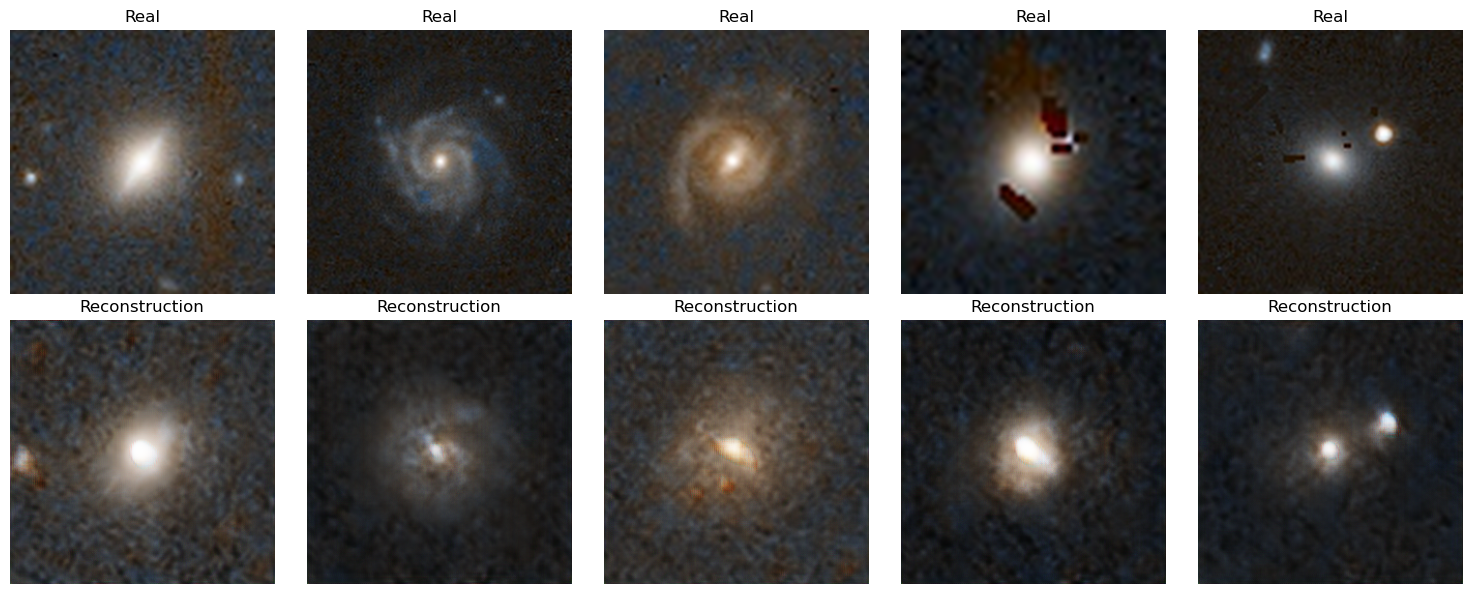

In [6]:
N = min(5, real_cpu.shape[0])
fig, axes = plt.subplots(2, N, figsize=(3*N, 6))

for i in range(N):
    axes[0, i].imshow(real_cpu[i].permute(1,2,0).numpy())
    axes[0, i].set_title("Real")
    axes[0, i].axis("off")

    axes[1, i].imshow(rec_imgs[i].permute(1,2,0).numpy())
    axes[1, i].set_title("Reconstruction")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()


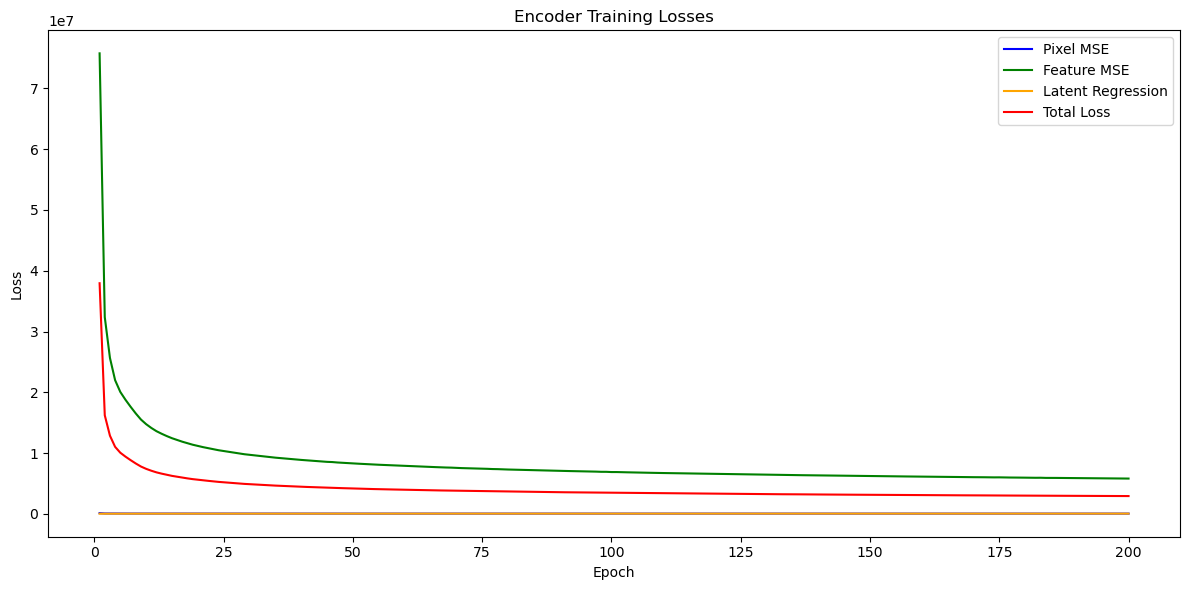

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt

ckpt_dir = "./outputs/encoder_checkpoints"

# Find all saved epoch loss files
loss_files = sorted([
    f for f in os.listdir(ckpt_dir)
    if f.startswith("losses_epoch_") and f.endswith(".npy")
])

if not loss_files:
    print("No encoder loss files found.")
else:
    img_losses = []
    feat_losses = []
    latent_losses = []
    total_losses = []

    for f in loss_files:
        arr = np.load(os.path.join(ckpt_dir, f), allow_pickle=True)
        # arr is [img_loss, feat_loss, latent_loss, total_loss]
        img_losses.append(arr[0])
        feat_losses.append(arr[1])
        latent_losses.append(arr[2])
        total_losses.append(arr[3])

    epochs = np.arange(1, len(img_losses) + 1)

    plt.figure(figsize=(12,6))
    plt.plot(epochs, img_losses, label="Pixel MSE", color="blue")
    plt.plot(epochs, feat_losses, label="Feature MSE", color="green")
    plt.plot(epochs, latent_losses, label="Latent Regression", color="orange")
    plt.plot(epochs, total_losses, label="Total Loss", color="red")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Encoder Training Losses")
    plt.legend()
    plt.tight_layout()
    plt.show()


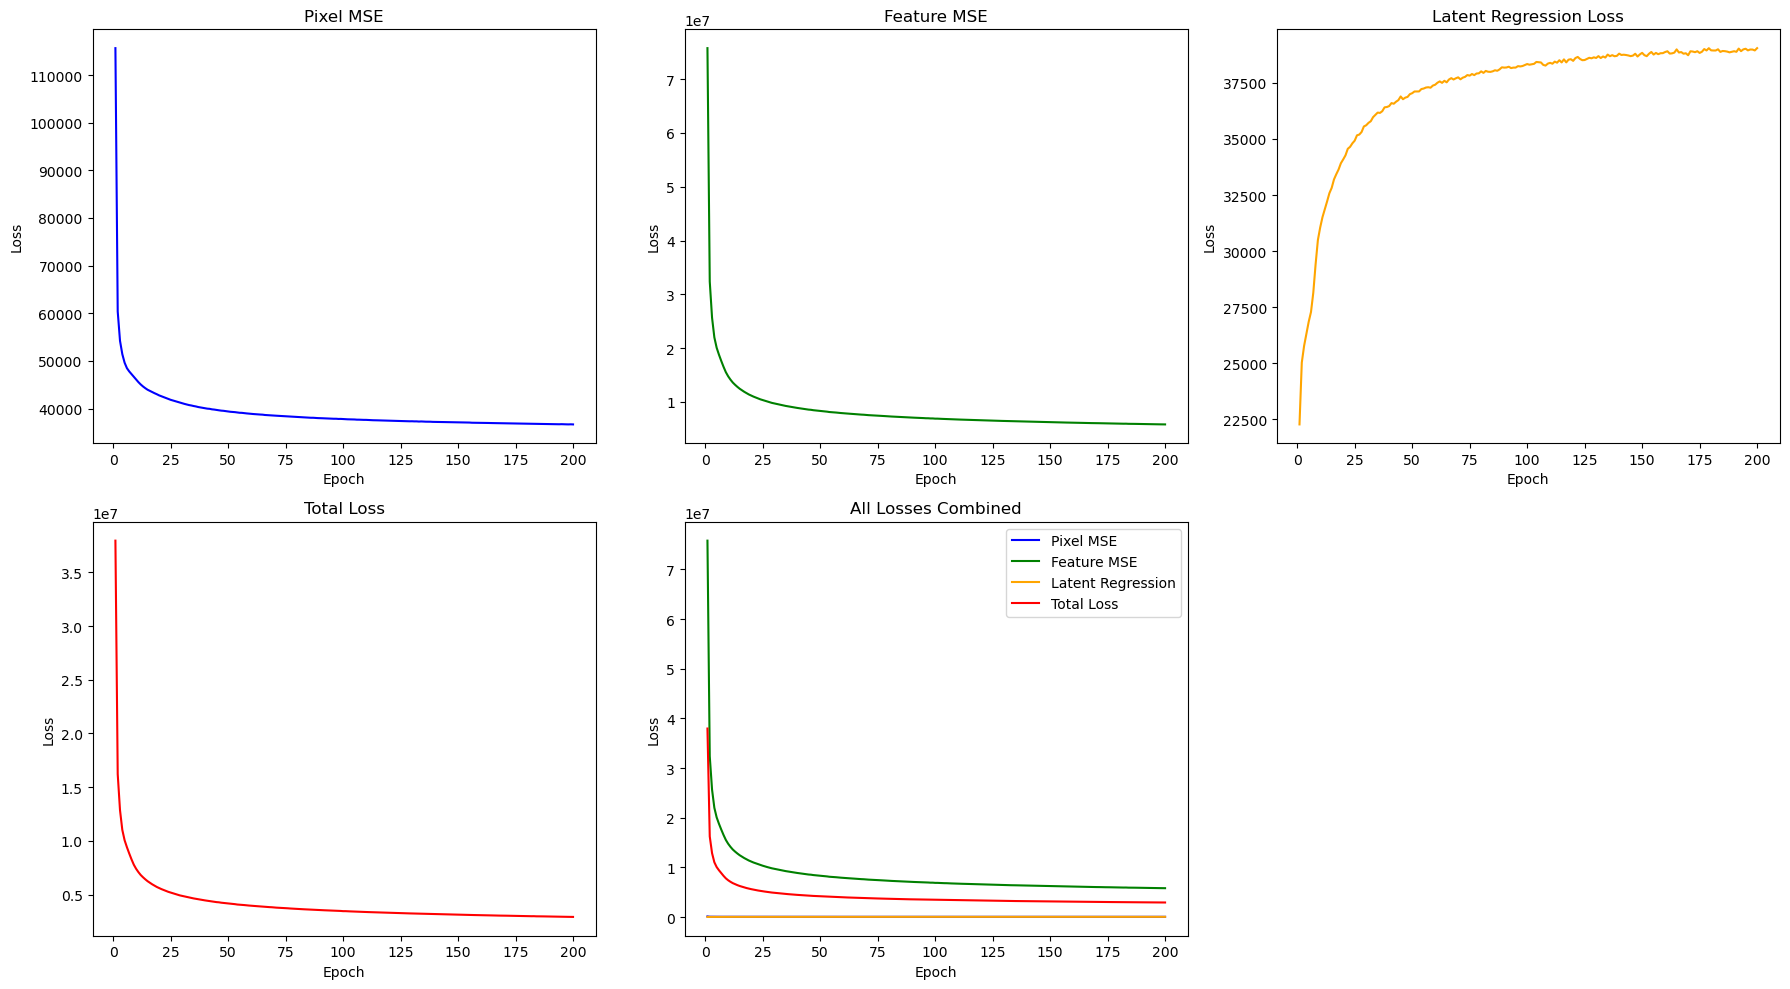

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt

# plt.rcParams["font.size"] = 18          # base font size
# plt.rcParams["axes.titlesize"] = 22     # subplot titles
# plt.rcParams["axes.labelsize"] = 20     # x/y labels
# plt.rcParams["xtick.labelsize"] = 16    # tick labels
# plt.rcParams["ytick.labelsize"] = 16
# plt.rcParams["legend.fontsize"] = 16    # legend text


ckpt_dir = "./outputs/encoder_checkpoints"

# Find all saved epoch loss files
loss_files = sorted([
    f for f in os.listdir(ckpt_dir)
    if f.startswith("losses_epoch_") and f.endswith(".npy")
])

if not loss_files:
    print("No encoder loss files found.")
else:
    img_losses = []
    feat_losses = []
    latent_losses = []
    total_losses = []

    for f in loss_files:
        arr = np.load(os.path.join(ckpt_dir, f), allow_pickle=True)
        img_losses.append(arr[0])
        feat_losses.append(arr[1])
        latent_losses.append(arr[2])
        total_losses.append(arr[3])

    epochs = np.arange(1, len(img_losses) + 1)

    # ---- 2 rows × 3 columns ----
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # Pixel MSE
    axes[0, 0].plot(epochs, img_losses, color="blue")
    axes[0, 0].set_title("Pixel MSE")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss")

    # Feature MSE
    axes[0, 1].plot(epochs, feat_losses, color="green")
    axes[0, 1].set_title("Feature MSE")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("Loss")

    # Latent Regression
    axes[0, 2].plot(epochs, latent_losses, color="orange")
    axes[0, 2].set_title("Latent Regression Loss")
    axes[0, 2].set_xlabel("Epoch")
    axes[0, 2].set_ylabel("Loss")

    # Total Loss
    axes[1, 0].plot(epochs, total_losses, color="red")
    axes[1, 0].set_title("Total Loss")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("Loss")

    # Combined Plot
    axes[1, 1].plot(epochs, img_losses, label="Pixel MSE", color="blue")
    axes[1, 1].plot(epochs, feat_losses, label="Feature MSE", color="green")
    axes[1, 1].plot(epochs, latent_losses, label="Latent Regression", color="orange")
    axes[1, 1].plot(epochs, total_losses, label="Total Loss", color="red")
    axes[1, 1].set_title("All Losses Combined")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("Loss")
    axes[1, 1].legend()

    # Empty subplot (bottom-right)
    axes[1, 2].axis("off")

    plt.tight_layout()
    plt.show()
